In [63]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [64]:
!pip install rdkit

In [65]:
# For Chemical Analysis
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, AllChem, rdFingerprintGenerator
    from rdkit.Chem import Draw
    from IPython.display import display
except ImportError:
    print("RDKit not available")
    Chem = None

In [66]:
# CSV file
df = pd.read_csv("/content/drive/MyDrive/playground-series-s6e2 (2)/tox21.csv")

In [67]:
print(f"Shape: {df.shape}")
df.info()

Shape: (7831, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB


In [68]:
# First Rows
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



First 8 molecules:


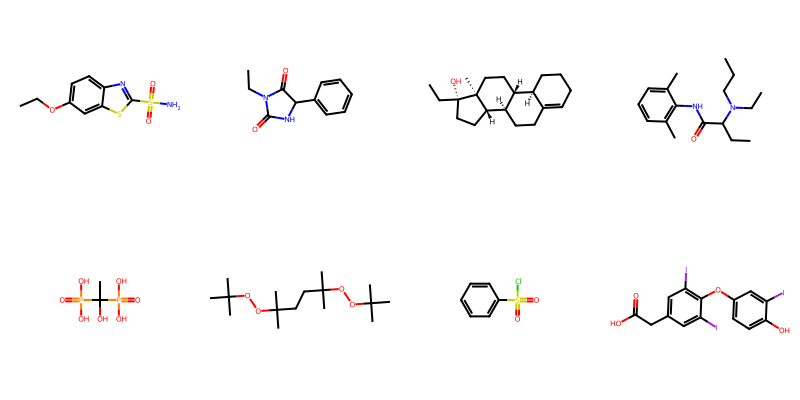

In [69]:
# Visualize first 8 molecules as a grid
print("\nFirst 8 molecules:")
mol_objs = [Chem.MolFromSmiles(s) for s in df['smiles'].head(8)]
img = Draw.MolsToGridImage(mol_objs, molsPerRow=4, subImgSize=(200,200))
display(img)

In [70]:
# Missing Data
missing_data = df.isnull().sum()
missing_data_percent = df.isnull().mean()*100
print("\nMissing Data:")
print(missing_data)


Missing Data:
NR-AR             566
NR-AR-LBD        1073
NR-AhR           1282
NR-Aromatase     2010
NR-ER            1638
NR-ER-LBD         876
NR-PPAR-gamma    1381
SR-ARE           1999
SR-ATAD5          759
SR-HSE           1364
SR-MMP           2021
SR-p53           1057
mol_id              0
smiles              0
dtype: int64


In [71]:
missing_data_df = pd.DataFrame({'Missing Data': missing_data, 'Missing Data (%)': missing_data_percent}).sort_values(by='Missing Data', ascending=False)
print("\nMissing Data:")
print(missing_data_df)


Missing Data:
               Missing Data  Missing Data (%)
SR-MMP                 2021         25.807687
NR-Aromatase           2010         25.667220
SR-ARE                 1999         25.526753
NR-ER                  1638         20.916869
NR-PPAR-gamma          1381         17.635040
SR-HSE                 1364         17.417954
NR-AhR                 1282         16.370834
NR-AR-LBD              1073         13.701954
SR-p53                 1057         13.497638
NR-ER-LBD               876         11.186311
SR-ATAD5                759          9.692249
NR-AR                   566          7.227685
mol_id                    0          0.000000
smiles                    0          0.000000


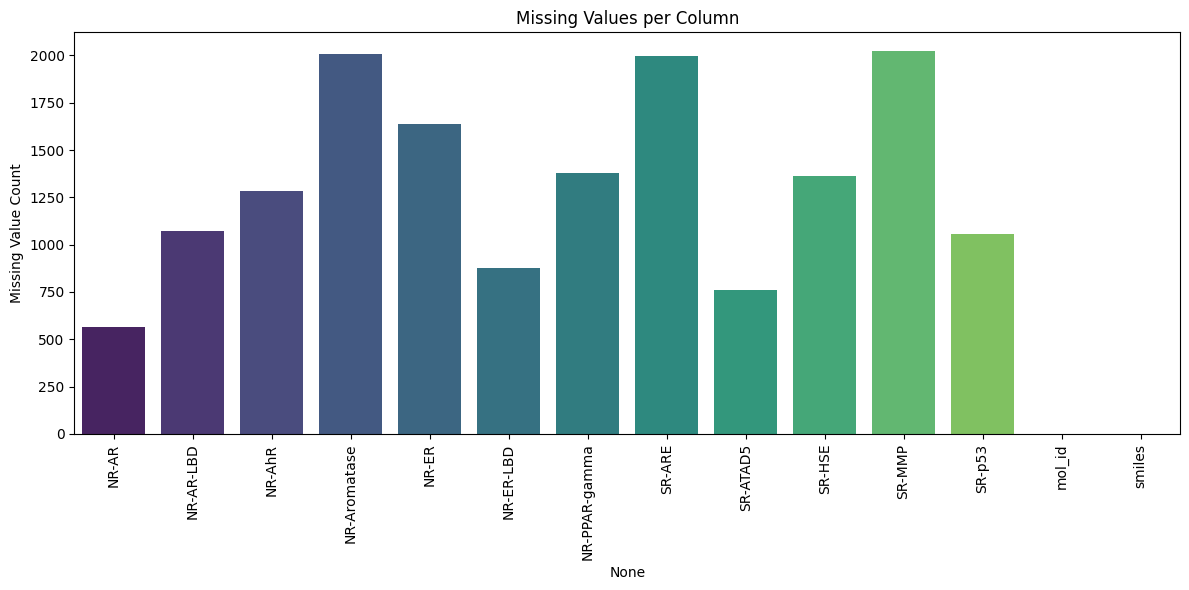

In [72]:
# Visualize missing data
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis',hue=missing_data.index)
plt.xticks(rotation=90)
plt.ylabel('Missing Value Count')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [73]:
# Bioactivity target columns (exclude IDs and SMILES)
target_cols = [c for c in df.columns if c not in ['mol_id', 'smiles']]
print(f"\nFound {len(target_cols)} target columns:")
for i, col in enumerate(target_cols, 1):
    print(f"{i:2d}. {col}")


Found 12 target columns:
 1. NR-AR
 2. NR-AR-LBD
 3. NR-AhR
 4. NR-Aromatase
 5. NR-ER
 6. NR-ER-LBD
 7. NR-PPAR-gamma
 8. SR-ARE
 9. SR-ATAD5
10. SR-HSE
11. SR-MMP
12. SR-p53


In [74]:
# Compute correlations among targets (ignoring NaNs)
corr = df[target_cols].corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:  # threshold for high correlation
            high_corr_pairs.append({
                'Target1': corr.columns[i],
                'Target2': corr.columns[j],
                'Correlation': corr.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\nHighly correlated target pairs (|r| > 0.5):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    display(high_corr_df)


Highly correlated target pairs (|r| > 0.5):


,Target1,Target2,Correlation
0,NR-AR,NR-AR-LBD,0.567408
1,NR-ER,NR-ER-LBD,0.541272


Feature Extraction

In [75]:
# Molecular Descriptors

In [76]:
def mol_features(smiles):
    """Calculate molecular features from SMILES"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 8

    mol_wt = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    aromatic_rings = Descriptors.NumAromaticRings(mol)
    tpsa = Descriptors.TPSA(mol)
    num_atoms = mol.GetNumAtoms()

    return [mol_wt, logp, hbd, hba, rotatable_bonds, aromatic_rings, tpsa, num_atoms]

In [77]:
feature_names = ["MolWt", "LogP", "HBD", "HBA", "RotBonds", "AromaticRings", "TPSA", "NumAtoms"]
df[feature_names] = df['smiles'].apply(lambda x: pd.Series(mol_features(x)))

[10:23:39] WARNING: not removing hydrogen atom without neighbors
[10:23:42] Explicit valence for atom # 8 Al, 6, is greater than permitted
[10:23:45] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:23:45] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:23:48] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:23:50] Explicit valence for atom # 9 Al, 6, is greater than permitted
[10:23:50] Explicit valence for atom # 5 Al, 6, is greater than permitted
[10:23:54] Explicit valence for atom # 16 Al, 6, is greater than permitted
[10:23:59] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [78]:
print("Molecular descriptor statistics:")
display(df[feature_names].describe())

Molecular descriptor statistics:


,MolWt,LogP,HBD,HBA,RotBonds,AromaticRings,TPSA,NumAtoms
count,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000
mean,276.144155,2.373943,1.224978,3.473987,4.302697,1.101496,59.472201,18.567813
std,164.732356,2.304307,1.916035,3.115448,4.464772,1.095971,57.794990,11.309695
min,9.012000,-17.406400,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,165.236000,1.149350,0.000000,2.000000,1.000000,0.000000,26.300000,11.000000
50%,240.302000,2.365500,1.000000,3.000000,3.000000,1.000000,46.530000,16.000000
75%,343.044000,3.653150,2.000000,4.000000,6.000000,2.000000,77.030000,23.000000
max,1877.664000,22.611800,30.000000,46.000000,47.000000,12.000000,777.980000,132.000000


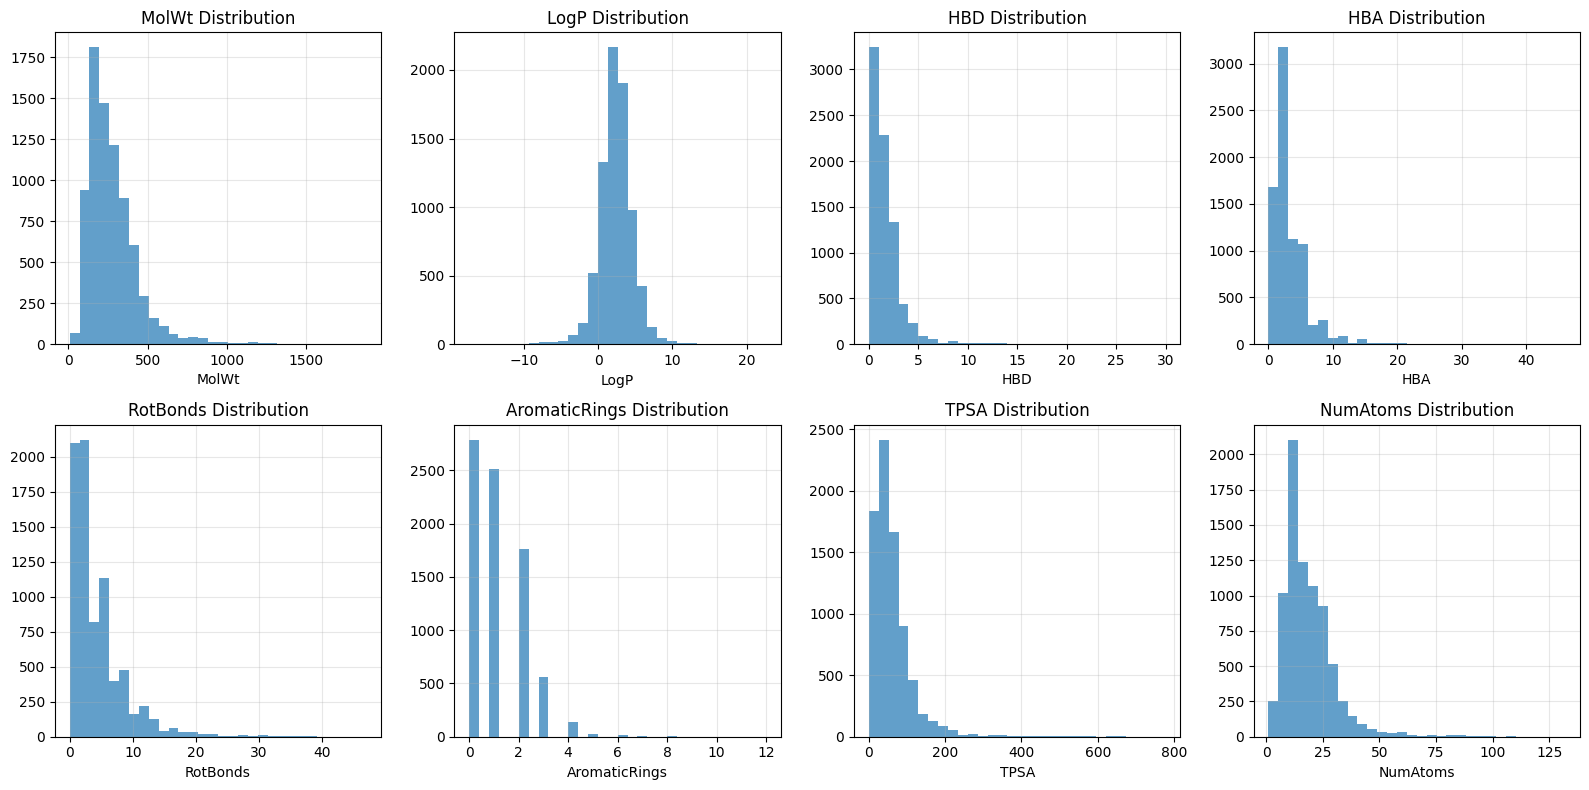

In [79]:
# Plot distributions of molecular features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    df[feature].hist(bins=30, ax=axes[i], alpha=0.7)
    axes[i].set_xlabel(feature)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

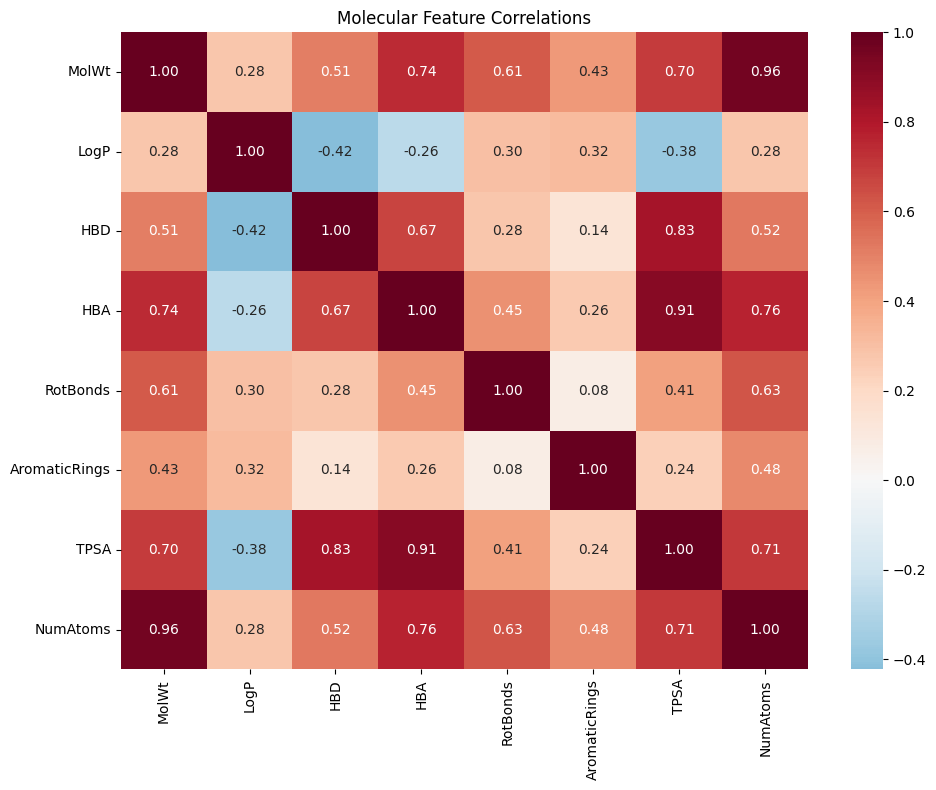

In [80]:
# Correlation between molecular features
plt.figure(figsize=(10, 8))
feature_corr = df[feature_names].corr()
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Molecular Feature Correlations')
plt.tight_layout()
plt.show()

In [81]:
# Morgan Fingerprints

In [82]:
print("\nGenerating Morgan fingerprints...")
# Modern MorganGenerator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def fingerprint(smiles, generator):
    """Generate Morgan fingerprint for a molecule"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0] * generator.GetOptions().fpSize
    return list(generator.GetFingerprint(mol))

# Generate fingerprints for all molecules
print("Calculating fingerprints... (this may take a moment)")
X_fps = np.array(df['smiles'].apply(fingerprint, args=(morgan_gen,)).tolist())
print(f"Fingerprint matrix shape: {X_fps.shape}")
print(f"Fingerprint sparsity: {(X_fps == 0).mean():.3f}")


Generating Morgan fingerprints...
Calculating fingerprints... (this may take a moment)


[10:24:06] WARNING: not removing hydrogen atom without neighbors
[10:24:10] Explicit valence for atom # 8 Al, 6, is greater than permitted
[10:24:13] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:24:13] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:24:15] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:24:16] Explicit valence for atom # 9 Al, 6, is greater than permitted
[10:24:16] Explicit valence for atom # 5 Al, 6, is greater than permitted
[10:24:17] Explicit valence for atom # 16 Al, 6, is greater than permitted
[10:24:18] Explicit valence for atom # 20 Al, 6, is greater than permitted


Fingerprint matrix shape: (7831, 2048)
Fingerprint sparsity: 0.985


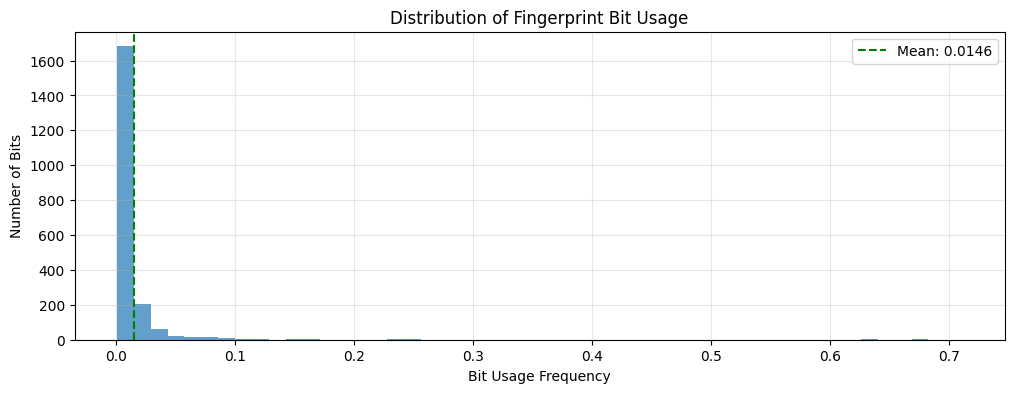

In [83]:
# Analyze fingerprint bit usage
bit_usage = X_fps.mean(axis=0)
plt.figure(figsize=(12, 4))
plt.hist(bit_usage, bins=50, alpha=0.7)
plt.xlabel('Bit Usage Frequency')
plt.ylabel('Number of Bits')
plt.title('Distribution of Fingerprint Bit Usage')
plt.axvline(bit_usage.mean(), color='green', linestyle='--',
            label=f'Mean: {bit_usage.mean():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Machine Learning Analysis

In [84]:
# Select targets with sufficient positive samples for modeling
min_positive_samples = 50
viable_targets = []

for target in target_cols:
    positive_count = (df[target] == 1.0).sum()
    total_count = df[target].notna().sum()

    if positive_count >= min_positive_samples and total_count >= 100:
        viable_targets.append({
            'target': target,
            'positive_samples': positive_count,
            'total_samples': total_count,
            'positive_rate': positive_count / total_count
        })

viable_targets_df = pd.DataFrame(viable_targets).sort_values('positive_rate', ascending=False)
print(f"\nTargets viable for modeling (≥{min_positive_samples} positive samples):")
display(viable_targets_df)


Targets viable for modeling (≥50 positive samples):


,target,positive_samples,total_samples,positive_rate
7,SR-ARE,942,5832,0.161523
10,SR-MMP,918,5810,0.158003
4,NR-ER,793,6193,0.128048
2,NR-AhR,768,6549,0.117270
11,SR-p53,423,6774,0.062445
9,SR-HSE,372,6467,0.057523
3,NR-Aromatase,300,5821,0.051538
5,NR-ER-LBD,350,6955,0.050324
0,NR-AR,309,7265,0.042533
8,SR-ATAD5,264,7072,0.037330


In [85]:
# Prepare features: combine molecular descriptors and fingerprints
X_descriptors = df[feature_names].fillna(0).values
X_combined = np.hstack([X_descriptors, X_fps])
print(f"Combined feature matrix shape: {X_combined.shape}")

Combined feature matrix shape: (7831, 2056)


In [86]:
from xgboost import XGBClassifier

In [87]:
results = []

# Use only viable targets (recommended)
targets_to_use = viable_targets_df['target'].tolist()

for target in targets_to_use:
    print(f"Training for TARGET: {target}")

    # Remove NaNs for this target
    mask = df[target].notna()
    X = X_combined[mask]
    y = df.loc[mask, target].values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

    # Handle imbalance
    ratio = (len(y_train) - sum(y_train)) / sum(y_train)

    # 🌲 RANDOM FOREST

    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    rf_proba = rf.predict_proba(X_test)[:, 1]
    rf_auc = roc_auc_score(y_test, rf_proba)

    print(f"RF AUC: {rf_auc:.4f}")


    # LOGISTIC REGRESSION

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    lr.fit(X_train_scaled, y_train)

    lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
    lr_auc = roc_auc_score(y_test, lr_proba)

    print(f"LR AUC: {lr_auc:.4f}")


    #  XGBOOST (BEST)

    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train, y_train)

    xgb_proba = xgb.predict_proba(X_test)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_proba)

    print(f"XGB AUC: {xgb_auc:.4f}")


    #  BEST MODEL SELECTION

    best_model = "Random Forest"
    best_auc = rf_auc

    if lr_auc > best_auc:
        best_model = "Logistic Regression"
        best_auc = lr_auc

    if xgb_auc > best_auc:
        best_model = "XGBoost"
        best_auc = xgb_auc

    print(f"Best Model: {best_model} (AUC: {best_auc:.4f})")


    #  CLASSIFICATION REPORT (for best model)

    if best_model == "Random Forest":
        y_pred = (rf_proba > 0.3).astype(int)
    elif best_model == "Logistic Regression":
        y_pred = (lr_proba > 0.3).astype(int)
    else:
        y_pred = (xgb_proba > 0.3).astype(int)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # STORE RESULTS

    results.append({
        "Target": target,
        "RF_AUC": rf_auc,
        "LR_AUC": lr_auc,
        "XGB_AUC": xgb_auc,
        "Best_Model": best_model,
        "Best_AUC": best_auc,
        "Train_Size": len(y_train),
        "Test_Size": len(y_test)
    })


Training for TARGET: SR-ARE
Train size: 4665, Test size: 1167
RF AUC: 0.8558
LR AUC: 0.7472
XGB AUC: 0.8405
Best Model: Random Forest (AUC: 0.8558)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.90      0.91       979
         1.0       0.55      0.62      0.58       188

    accuracy                           0.86      1167
   macro avg       0.74      0.76      0.75      1167
weighted avg       0.86      0.86      0.86      1167

Training for TARGET: SR-MMP
Train size: 4648, Test size: 1162
RF AUC: 0.9223
LR AUC: 0.7868
XGB AUC: 0.9323
Best Model: XGBoost (AUC: 0.9323)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.80      0.88       978
         1.0       0.46      0.92      0.61       184

    accuracy                           0.82      1162
   macro avg       0.72      0.86      0.75      1162
weighted avg       0.90      0.82      0.84      1162

Training

In [88]:
#  FINAL RESULTS TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Best_AUC", ascending=False)

print("\n FINAL RESULTS:")
display(results_df)


 FINAL RESULTS:


,Target,RF_AUC,LR_AUC,XGB_AUC,Best_Model,Best_AUC,Train_Size,Test_Size
1,SR-MMP,0.922338,0.786838,0.932338,XGBoost,0.932338,4648,1162
9,SR-ATAD5,0.914755,0.744826,0.874061,Random Forest,0.914755,5657,1415
3,NR-AhR,0.914242,0.807004,0.895098,Random Forest,0.914242,5239,1310
6,NR-Aromatase,0.886342,0.803937,0.878507,Random Forest,0.886342,4656,1165
4,SR-p53,0.885058,0.689625,0.881204,Random Forest,0.885058,5419,1355
0,SR-ARE,0.855766,0.747202,0.840510,Random Forest,0.855766,4665,1167
11,NR-PPAR-gamma,0.841688,0.772265,0.848019,XGBoost,0.848019,5160,1290
5,SR-HSE,0.825260,0.630439,0.776506,Random Forest,0.825260,5173,1294
7,NR-ER-LBD,0.813350,0.737299,0.811517,Random Forest,0.813350,5564,1391
10,NR-AR-LBD,0.801736,0.768240,0.781136,Random Forest,0.801736,5406,1352


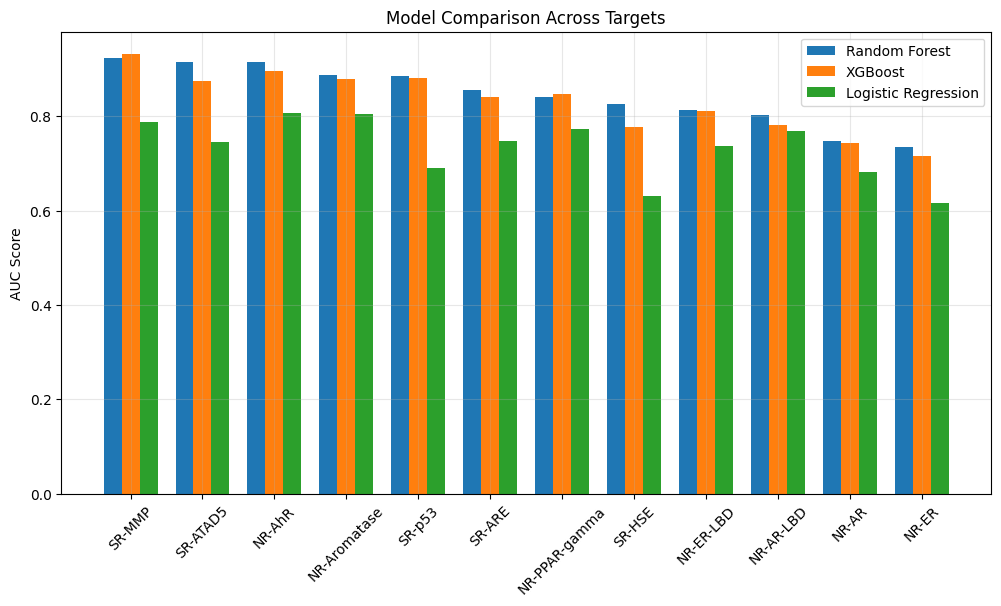

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

x = np.arange(len(results_df))

plt.bar(x-0.25, results_df['RF_AUC'], 0.25, label='Random Forest')
plt.bar(x, results_df['XGB_AUC'], 0.25, label='XGBoost')
plt.bar(x+0.25, results_df['LR_AUC'], 0.25, label='Logistic Regression')

plt.xticks(x, results_df['Target'], rotation=45)
plt.ylabel("AUC Score")
plt.title("Model Comparison Across Targets")
plt.legend()
plt.grid(alpha=0.3)

plt.show()